In [1]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import re
import json
import logging
import warnings
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from dataclasses import dataclass, field
from collections import defaultdict

# ─── Data Science ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─── NLP ─────────────────────────────────────────────────────────────────────
import unicodedata

# ─── Suppress non-critical warnings ──────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

# ─── Logging Setup ────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("mimic_nlp")

# ─── Plotting Defaults ────────────────────────────────────────────────────────
sns.set_style("darkgrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Imports complete.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Imports complete.
   pandas  : 2.3.3
   numpy   : 2.4.6


In [3]:
# --------------------------------------------------------------
# Section 2 — Configuration
# --------------------------------------------------------------

from dataclasses import dataclass, field
from typing import List

@dataclass
class Config:
    """Central configuration for the MIMIC‑CXR label‑generation pipeline."""

    # ── Paths ─────────────────────────────────────────────────────────────
    # Root directory where the Kaggle dataset is mounted.
    dataset_root: str = "/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset"

    # Output directory for all generated artefacts (CSV, JSON, plots, etc.).
    output_dir: str = "/kaggle/working"

    # Images are stored under the official_data_iccv_final folder; the
    # actual image files live in the nested “files/” sub‑directory.
    image_subroot: str = "official_data_iccv_final/files"

    # ── CSV filenames ───────────────────────────────────────────────────
    train_csv: str = "mimic_cxr_aug_train.csv"
    val_csv:   str = "mimic_cxr_aug_validate.csv"

    # ── Output filenames ─────────────────────────────────────────────────
    out_train_csv: str = "mimic_final_labeled_train.csv"
    out_val_csv:   str = "mimic_final_labeled_validate.csv"
    out_stats_json: str = "label_statistics.json"

    # ── Target disease labels ────────────────────────────────────────────
    targets: List[str] = field(default_factory=lambda: [
        "No Finding",
        "Cardiomegaly",
        "Edema",
        "Pleural Effusion",
        "Pneumonia",
        "Pneumothorax",
    ])

    # ── Uncertainty handling policy ─────────────────────────────────────
    #   "ones"  → uncertain mentions become 1 (conservative)
    #   "zeros" → uncertain mentions become 0
    #   "ignore"→ uncertain mentions become NaN
    uncertainty_policy: str = "ones"

    # ── View preference when selecting a single image per study ────────
    # Priority order: PA → AP → first available (non‑lateral)
    view_priority: List[str] = field(default_factory=lambda: ["PA", "AP"])

    # ── Validation / inspection parameters ───────────────────────────────
    inspection_sample_n: int = 100   # how many studies to dump for manual review
    random_seed: int = 42            # reproducibility seed


# ----------------------------------------------------------------------
# Derived (runtime) paths – no need to edit them
# ----------------------------------------------------------------------
CFG = Config()

OUTPUT_DIR = Path(CFG.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ROOT = Path(CFG.dataset_root)                     # ↦ /kaggle/input/…/mimic-cxr-dataset
IMAGE_ROOT   = DATASET_ROOT / CFG.image_subroot           # ↦ /kaggle/input/.../official_data_iccv_final/files

# ----------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------
random.seed(CFG.random_seed)
np.random.seed(CFG.random_seed)

# ----------------------------------------------------------------------
# Quick sanity‑print
# ----------------------------------------------------------------------
print("✅ Configuration loaded.")
print(f"   Dataset root : {DATASET_ROOT}")
print(f"   Image root   : {IMAGE_ROOT}")
print(f"   Output dir   : {OUTPUT_DIR}")
print(f"   Targets      : {CFG.targets}")
print(f"   Uncertainty  : {CFG.uncertainty_policy}")


✅ Configuration loaded.
   Dataset root : /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset
   Image root   : /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final/files
   Output dir   : /kaggle/working
   Targets      : ['No Finding', 'Cardiomegaly', 'Edema', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax']
   Uncertainty  : ones


In [4]:
def discover_dataset(base: Path) -> Dict[str, Path]:
    """
    Walk the base directory to locate required CSV files.

    Parameters
    ----------
    base : Path
        Root directory to search.

    Returns
    -------
    Dict[str, Path]
        Mapping of filename → absolute Path.
    """
    required = {CFG.train_csv, CFG.val_csv}
    found: Dict[str, Path] = {}

    if not base.exists():
        raise FileNotFoundError(
            f"Dataset root does not exist: {base}\n"
            "Make sure the Kaggle dataset is attached to this notebook."
        )

    for root, dirs, files in os.walk(base):
        for f in files:
            if f in required:
                found[f] = Path(root) / f
        if len(found) == len(required):
            break

    missing = required - set(found.keys())
    if missing:
        raise FileNotFoundError(f"Could not locate CSV files: {missing}")

    return found


csv_paths = discover_dataset(DATASET_ROOT)

print("✅ Dataset files discovered:")
for name, path in csv_paths.items():
    size_mb = path.stat().st_size / 1_048_576
    print(f"   {name}  →  {path}  ({size_mb:.1f} MB)")

print()
print(f"   Image root exists : {IMAGE_ROOT.exists()}")
if IMAGE_ROOT.exists():
    n_dirs = sum(1 for _ in IMAGE_ROOT.iterdir() if _.is_dir())
    print(f"   Top-level dirs    : {n_dirs}")

✅ Dataset files discovered:
   mimic_cxr_aug_validate.csv  →  /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/mimic_cxr_aug_validate.csv  (1.8 MB)
   mimic_cxr_aug_train.csv  →  /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/mimic_cxr_aug_train.csv  (224.9 MB)

   Image root exists : True
   Top-level dirs    : 10


In [5]:
# ── Columns to drop if present ────────────────────────────────────────────────
DROP_COLS = ["Unnamed: 0", "Unnamed: 0.1"]

# ── Required columns after load ───────────────────────────────────────────────
REQUIRED_COLS = ["subject_id", "image", "view", "AP", "PA", "Lateral", "text"]


def load_csv(path: Path, split_name: str) -> pd.DataFrame:
    """
    Load a MIMIC-CXR CSV file with robust error handling.

    Parameters
    ----------
    path : Path
        Path to the CSV file.
    split_name : str
        Human-readable split label (e.g. 'train', 'validate').

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe with required columns.
    """
    logger.info("Loading %s split from: %s", split_name, path)
    df = pd.read_csv(path, low_memory=False)

    # Drop artefact columns
    drop_existing = [c for c in DROP_COLS if c in df.columns]
    if drop_existing:
        df.drop(columns=drop_existing, inplace=True)
        logger.info("  Dropped columns: %s", drop_existing)

    # Validate required columns
    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        logger.warning("  Missing columns: %s — they will be filled with NaN", missing_cols)
        for c in missing_cols:
            df[c] = np.nan

    # Ensure string types
    for col in ["subject_id", "image", "view", "text"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Replace 'nan' strings produced by astype(str) on actual NaN values
    for col in ["text", "image", "view"]:
        df[col] = df[col].replace("nan", np.nan)

    logger.info("  Loaded %d rows × %d cols", len(df), len(df.columns))
    return df


df_train = load_csv(csv_paths[CFG.train_csv], "train")
df_val   = load_csv(csv_paths[CFG.val_csv],   "validate")

print("\n📊 Dataset Summary")
print(f"   Train split     : {len(df_train):>8,} rows")
print(f"   Validate split  : {len(df_val):>8,} rows")
print(f"   Columns         : {list(df_train.columns)}")

print("\n🔍 Train sample:")
df_train.head(3)

04:50:29  INFO      Loading train split from: /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/mimic_cxr_aug_train.csv
04:50:34  INFO        Dropped columns: ['Unnamed: 0', 'Unnamed: 0.1']
04:50:34  INFO        Loaded 64586 rows × 8 cols
04:50:34  INFO      Loading validate split from: /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/mimic_cxr_aug_validate.csv
04:50:34  INFO        Dropped columns: ['Unnamed: 0', 'Unnamed: 0.1']
04:50:34  INFO        Loaded 500 rows × 8 cols



📊 Dataset Summary
   Train split     :   64,586 rows
   Validate split  :      500 rows
   Columns         : ['subject_id', 'image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment']

🔍 Train sample:


,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,10000032,"['files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg', 'files/p10/p10000032/s50414267/17...","['PA', 'LATERAL', 'AP']","['files/p10/p10000032/s53911762/68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg', 'files/p10/p10000032/s53911762/ff...","['files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg', 'files/p10/p10000032/s53189527/2a...","['files/p10/p10000032/s50414267/174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962.jpg', 'files/p10/p10000032/s53189527/e0...","['Findings: There is no focal consolidation, pleural effusion or pneumothorax. Bilateral nodular opacities that mos...","['Findings: There is no focus, pleural effusion or pneumothorax. Bilateral nickular turbidities, which probably repr..."
1,10000764,"['files/p10/p10000764/s57375967/096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4.jpg', 'files/p10/p10000764/s57375967/b7...","['AP', 'LATERAL']",['files/p10/p10000764/s57375967/096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4.jpg'],[],"['files/p10/p10000764/s57375967/b79e55c3-735ce5ac-64412506-cdc9ea79-f1af521f.jpg', 'files/p10/p10000764/s57375967/dc...",['Findings: PA and lateral views of the chest provided. The lungs are adequately aerated. There is a focal consol...,['Finds: PA and lateral view of the breast intended. The lungs are sufficiently ventilated. There is a focal consoli...
2,10000898,"['files/p10/p10000898/s50771383/0c4eb1e1-b801903c-bcebe8a4-3da9cd3c-3b94a27c.jpg', 'files/p10/p10000898/s50771383/2a...","['LATERAL', 'PA']",[],"['files/p10/p10000898/s50771383/2a280266-c8bae121-54d75383-cac046f4-ca37aa16.jpg', 'files/p10/p10000898/s54205396/b7...","['files/p10/p10000898/s50771383/0c4eb1e1-b801903c-bcebe8a4-3da9cd3c-3b94a27c.jpg', 'files/p10/p10000898/s54205396/89...",['Findings: PA and lateral views of the chest provided. Lung volumes are somewhat low. There is no focal consolida...,"['Finds: PA and side view of the chest provided. Lung volume are slightly low. There is no focusing, effusion or pne..."


In [6]:
# ── Null audit ────────────────────────────────────────────────────────────────
def null_audit(df: pd.DataFrame, name: str) -> None:
    """Print null-value percentages for each column."""
    print(f"\n📋 Null audit — {name}")
    audit = (df.isnull().sum() / len(df) * 100).round(2)
    for col, pct in audit.items():
        flag = " ⚠️" if pct > 10 else ""
        print(f"   {col:<25} {pct:>6.2f}%{flag}")


null_audit(df_train, "train")
null_audit(df_val, "validate")


📋 Null audit — train
   subject_id                  0.00%
   image                       0.00%
   view                        0.00%
   AP                          0.00%
   PA                          0.00%
   Lateral                     0.00%
   text                        0.00%
   text_augment                0.00%

📋 Null audit — validate
   subject_id                  0.00%
   image                       0.00%
   view                        0.00%
   AP                          0.00%
   PA                          0.00%
   Lateral                     0.00%
   text                        0.00%
   text_augment                0.00%


In [7]:
# ─── Clinical text cleaning utilities ─────────────────────────────────────────

_RE_MULTI_SPACE  = re.compile(r"\s+")
_RE_MULTI_PUNCT  = re.compile(r"([.,:;!?])\1+")
_RE_DEID_TOKENS  = re.compile(r"\[\*\*.*?\*\*\]")          # [**Patient Name**]
_RE_PAGE_HEADERS = re.compile(
    r"(?i)(impression|findings|history|indication|technique|comparison):\s*"
)


def normalize_unicode(text: str) -> str:
    """Convert non-ASCII characters to closest ASCII equivalent."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")


def clean_report(raw: Optional[str]) -> str:
    """
    Clinically-aware text cleaning for radiology reports.

    Pipeline
    --------
    1. Handle None / NaN
    2. Unicode normalisation
    3. Remove MIMIC de-identification tokens
    4. Lowercase
    5. Normalise punctuation
    6. Collapse whitespace

    Parameters
    ----------
    raw : Optional[str]
        Raw report text.

    Returns
    -------
    str
        Cleaned, lowercase report string. Empty string if input is null.
    """
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return ""

    text = str(raw)
    text = normalize_unicode(text)
    text = _RE_DEID_TOKENS.sub(" ", text)         # remove [**Name**] tokens
    text = text.lower()
    text = _RE_MULTI_PUNCT.sub(r"\1", text)        # '...' → '.'
    text = text.replace("/", " or ")
    text = text.replace("-", " ")
    text = _RE_MULTI_SPACE.sub(" ", text)
    return text.strip()


def select_report_text(row: pd.Series) -> str:
    """
    Select report text with fallback to text_augment.

    Priority: text → text_augment → ""
    """
    primary = row.get("text", None)
    if primary and str(primary).strip() not in ("", "nan", "none"):
        return clean_report(primary)

    fallback = row.get("text_augment", None)
    if fallback and str(fallback).strip() not in ("", "nan", "none"):
        return clean_report(fallback)

    return ""


# ── Apply to both splits ──────────────────────────────────────────────────────
df_train["report"] = df_train.apply(select_report_text, axis=1)
df_val["report"]   = df_val.apply(select_report_text, axis=1)

# ── Audit empty reports ───────────────────────────────────────────────────────
n_empty_train = (df_train["report"] == "").sum()
n_empty_val   = (df_val["report"]   == "").sum()

print("✅ Report cleaning complete.")
print(f"   Empty reports — train    : {n_empty_train:,} ({n_empty_train/len(df_train)*100:.2f}%)")
print(f"   Empty reports — validate : {n_empty_val:,} ({n_empty_val/len(df_val)*100:.2f}%)")
print("\n📝 Sample cleaned report:")
sample_text = df_train[df_train["report"] != ""]["report"].iloc[0]
print(f"   {sample_text[:400]}..." if len(sample_text) > 400 else f"   {sample_text}")

✅ Report cleaning complete.
   Empty reports — train    : 0 (0.00%)
   Empty reports — validate : 0 (0.00%)

📝 Sample cleaned report:
   ['findings: there is no focal consolidation, pleural effusion or pneumothorax. bilateral nodular opacities that most likely represent nipple shadows. the cardiomediastinal silhouette is normal. clips project over the left lung, potentially within the breast. the imaged upper abdomen is unremarkable. chronic deformity of the posterior left sixth and seventh ribs are noted. impression: no acute card...


In [8]:
# ─── Clinical keyword dictionary ──────────────────────────────────────────────
#
# Each list contains phrases (already lowercased).
# Longer / more specific phrases are listed first to avoid partial matches
# being shadowed by shorter ones during scanning.

KEYWORD_DICT: Dict[str, List[str]] = {
    "Cardiomegaly": [
        "cardiomegaly",
        "enlarged cardiac silhouette",
        "cardiac enlargement",
        "enlarged heart",
        "prominent cardiac silhouette",
        "increased cardiac size",
        "cardiac silhouette is enlarged",
    ],
    "Edema": [
        "pulmonary edema",
        "interstitial edema",
        "alveolar edema",
        "vascular congestion",
        "fluid overload",
        "pulmonary vascular congestion",
        "congestive heart failure",
        "chf",
        "pulmonary venous hypertension",
        "interstitial opacities",
        "Kerley b lines",
        "haziness",
    ],
    "Pleural Effusion": [
        "pleural effusion",
        "bilateral effusions",
        "bilateral pleural effusions",
        "small effusion",
        "moderate effusion",
        "large effusion",
        "pleural fluid",
        "blunting of the costophrenic angle",
        "blunting of costophrenic",
        "costophrenic blunting",
        "pleural space",
        "layering effusion",
    ],
    "Pneumonia": [
        "pneumonia",
        "airspace opacity",
        "airspace disease",
        "lobar consolidation",
        "consolidation",
        "infiltrate",
        "infiltration",
        "infectious process",
        "focal opacity",
        "parenchymal opacity",
        "atelectasis with pneumonia",
        "bronchopneumonia",
        "community acquired pneumonia",
    ],
    "Pneumothorax": [
        "pneumothorax",
        "collapsed lung",
        "lung collapse",
        "apical pneumothorax",
        "tension pneumothorax",
        "small pneumothorax",
        "iatrogenic pneumothorax",
    ],
}

# Uncertainty trigger phrases  ──────────────────────────────────────────────────
UNCERTAINTY_PHRASES: List[str] = [
    "cannot exclude",
    "cannot rule out",
    "can not exclude",
    "cannot be excluded",
    "possible",
    "possibly",
    "may represent",
    "could represent",
    "suspicious for",
    "consistent with",
    "suggestive of",
    "question of",
    "uncertain",
    "equivocal",
    "cannot be determined",
]

# Negation trigger phrases  ────────────────────────────────────────────────────
NEGATION_PHRASES: List[str] = [
    "no evidence of",
    "no sign of",
    "without evidence of",
    "negative for",
    "absence of",
    "free of",
    "not seen",
    "not identified",
    "not present",
    "not demonstrated",
    "not detected",
    "not visualized",
    "without",
    "no new",
    "no acute",
    "no",
]

print("✅ Keyword dictionaries defined.")
print(f"   Disease categories    : {list(KEYWORD_DICT.keys())}")
print(f"   Negation triggers     : {len(NEGATION_PHRASES)}")
print(f"   Uncertainty triggers  : {len(UNCERTAINTY_PHRASES)}")

✅ Keyword dictionaries defined.
   Disease categories    : ['Cardiomegaly', 'Edema', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax']
   Negation triggers     : 16
   Uncertainty triggers  : 15


In [9]:
# ─── Negation detection window size (tokens to look ahead from negation) ──────
NEGATION_WINDOW: int = 10   # words
UNCERTAINTY_WINDOW: int = 8  # words


def _split_into_sentences(text: str) -> List[str]:
    """
    Split cleaned report text into sentences for localised NLP.

    Uses period + space or newline as sentence boundaries.
    """
    # Split on period-space, newline, or semicolon
    parts = re.split(r"(?<=[.!?;])\s+|\n", text)
    return [p.strip() for p in parts if p.strip()]


def _context_window(text: str, keyword: str, n_words: int) -> str:
    """
    Extract `n_words` tokens to the LEFT of the keyword occurrence.

    Parameters
    ----------
    text : str
        Sentence or text segment (already lowercase).
    keyword : str
        The keyword whose left-context we want.
    n_words : int
        Number of words to the left to capture.

    Returns
    -------
    str
        Left-context substring.
    """
    idx = text.find(keyword)
    if idx == -1:
        return ""
    preceding = text[:idx]
    tokens = preceding.split()
    return " ".join(tokens[-n_words:])


def is_negated(sentence: str, keyword: str) -> bool:
    """
    Determine whether the keyword is negated within the sentence.

    Strategy
    --------
    Check if any NEGATION_PHRASE appears in the `NEGATION_WINDOW`-word
    left-context of the keyword.

    Parameters
    ----------
    sentence : str
        Single sentence (lowercase).
    keyword : str
        Disease keyword (lowercase).

    Returns
    -------
    bool
        True if the keyword is negated.
    """
    window = _context_window(sentence, keyword, NEGATION_WINDOW)
    for neg in NEGATION_PHRASES:
        if neg in window:
            return True
    return False


def is_uncertain(sentence: str, keyword: str) -> bool:
    """
    Determine whether the keyword mention is uncertain.

    Parameters
    ----------
    sentence : str
        Single sentence (lowercase).
    keyword : str
        Disease keyword (lowercase).

    Returns
    -------
    bool
        True if mention appears uncertain.
    """
    window = _context_window(sentence, keyword, UNCERTAINTY_WINDOW)
    for unc in UNCERTAINTY_PHRASES:
        if unc in window:
            return True
    return False


def _resolve_uncertainty(policy: str) -> Optional[int]:
    """
    Resolve uncertain findings to a label integer according to policy.

    Parameters
    ----------
    policy : str
        "ones", "zeros", or "ignore".

    Returns
    -------
    Optional[int]
        1, 0, or None.
    """
    if policy == "ones":
        return 1
    elif policy == "zeros":
        return 0
    else:
        return None   # NaN in the final DataFrame


def label_report(
    report: str,
    keyword_dict: Dict[str, List[str]],
    uncertainty_policy: str = "ones",
) -> Dict[str, Optional[int]]:
    """
    Generate binary disease labels from a cleaned radiology report.

    Algorithm (per disease, per sentence, per keyword)
    --------------------------------------------------
    1. Split report into sentences.
    2. For each sentence, search for disease keywords.
    3. If found:
       a. If negated  → 0
       b. If uncertain → resolve via uncertainty_policy
       c. Otherwise   → 1
    4. Aggregate across sentences: any positive evidence → label = 1.
    5. Apply No Finding rule:
       No Finding = 1 iff all other labels == 0.

    Parameters
    ----------
    report : str
        Cleaned radiology report text.
    keyword_dict : Dict[str, List[str]]
        Mapping of disease name → keyword phrase list.
    uncertainty_policy : str
        How to handle uncertain findings.

    Returns
    -------
    Dict[str, Optional[int]]
        Disease label dictionary. Values: 0, 1, or None.
    """
    if not report.strip():
        # Empty report → all labels unknown
        labels: Dict[str, Optional[int]] = {d: None for d in keyword_dict}
        labels["No Finding"] = None
        return labels

    sentences = _split_into_sentences(report)

    # Per-disease evidence accumulator: None=not seen, 0=negated, 1=positive
    evidence: Dict[str, Optional[int]] = {disease: None for disease in keyword_dict}

    for disease, keywords in keyword_dict.items():
        for sentence in sentences:
            for kw in keywords:
                if kw not in sentence:
                    continue
                # Keyword found in sentence
                if is_negated(sentence, kw):
                    # Only update to 0 if we have no positive evidence yet
                    if evidence[disease] != 1:
                        evidence[disease] = 0
                elif is_uncertain(sentence, kw):
                    resolved = _resolve_uncertainty(uncertainty_policy)
                    if resolved == 1 or evidence[disease] is None:
                        evidence[disease] = resolved
                else:
                    # Definitive positive
                    evidence[disease] = 1

    # Finalize: None → 0 (not mentioned = absent)
    labels = {d: (0 if v is None else v) for d, v in evidence.items()}

    # ── No Finding rule ───────────────────────────────────────────────────────
    # No Finding = 1 only when all pathology labels are 0
    pathology_labels = [labels[d] for d in keyword_dict]
    labels["No Finding"] = int(all(v == 0 for v in pathology_labels))

    return labels


# ── Quick sanity checks ───────────────────────────────────────────────────────
TEST_CASES = [
    ("no pleural effusion is identified.",
     "Pleural Effusion", 0),
    ("small bilateral pleural effusions are present.",
     "Pleural Effusion", 1),
    ("cannot exclude edema.",
     "Edema", 1),   # uncertain → ones policy
    ("no pneumothorax.",
     "Pneumothorax", 0),
    ("there is consolidation in the right lower lobe consistent with pneumonia.",
     "Pneumonia", 1),
    ("the cardiac silhouette is enlarged.",
     "Cardiomegaly", 1),
    ("no acute cardiopulmonary process.",
     "No Finding", 1),
]

print("🧪 Sanity checks on the labeller:")
all_pass = True
for text, disease, expected in TEST_CASES:
    result = label_report(clean_report(text), KEYWORD_DICT, CFG.uncertainty_policy)
    val = result.get(disease, "?")
    status = "✅" if val == expected else "❌"
    if val != expected:
        all_pass = False
    print(f"   {status}  [{disease:>18}] expected={expected}  got={val}  | '{text}'")

print()
print("✅ All sanity checks passed." if all_pass else "⚠️  Some checks failed — review keyword dictionary.")

🧪 Sanity checks on the labeller:
   ✅  [  Pleural Effusion] expected=0  got=0  | 'no pleural effusion is identified.'
   ✅  [  Pleural Effusion] expected=1  got=1  | 'small bilateral pleural effusions are present.'
   ❌  [             Edema] expected=1  got=0  | 'cannot exclude edema.'
   ✅  [      Pneumothorax] expected=0  got=0  | 'no pneumothorax.'
   ✅  [         Pneumonia] expected=1  got=1  | 'there is consolidation in the right lower lobe consistent with pneumonia.'
   ✅  [      Cardiomegaly] expected=1  got=1  | 'the cardiac silhouette is enlarged.'
   ✅  [        No Finding] expected=1  got=1  | 'no acute cardiopulmonary process.'

⚠️  Some checks failed — review keyword dictionary.


In [12]:
# --------------------------------------------------------------
# Section 8 — Image Selection & Path Construction (fixed)
# --------------------------------------------------------------

import ast
from pathlib import Path
from typing import List, Optional, Tuple

# ------------------------------------------------------------------
# 1️⃣  Study‑ID extraction (unchanged)
# ------------------------------------------------------------------
_RE_STUDY_ID = re.compile(r"(s\d+)", re.IGNORECASE)


def extract_study_id(image_path: str) -> str:
    """
    Extract the study identifier (e.g. ``s50414267``) from an image path.
    Returns an empty string if nothing matches.
    """
    match = _RE_STUDY_ID.search(str(image_path))
    return match.group(1).lower() if match else ""


# ------------------------------------------------------------------
# 2️⃣  Build a single absolute image path from a *candidate* string
# ------------------------------------------------------------------
def _candidate_path(image_rel: str, image_root: Path) -> Path:
    """
    Helper – combine ``image_root`` with a *single* relative path.
    The function does **not** check existence; it simply returns a Path.
    """
    return image_root / image_rel


# ------------------------------------------------------------------
# 3️⃣  Resolve the raw CSV ``image`` entry to a list of candidate strings
# ------------------------------------------------------------------
def _normalise_image_entry(entry: Union[str, List[str]]) -> List[str]:
    """
    The CSV may store a plain string (single path) **or** a stringified Python list.
    This helper always returns a *list* of clean, stripped path strings.
    """
    # Empty / NaN cases ------------------------------------------------
    if entry is None or (isinstance(entry, float) and pd.isna(entry)):
        return []

    # If we already have a Python list (unlikely but safe) ----------------
    if isinstance(entry, list):
        return [str(p).strip() for p in entry if p]

    # At this point we have a string.
    txt = str(entry).strip()

    # Detect the ``['...','...']`` pattern and safely evaluate it.
    if txt.startswith("[") and txt.endswith("]"):
        try:
            # ast.literal_eval safely parses the list without executing code.
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, list):
                return [str(p).strip() for p in parsed if p]
        except Exception:
            # If parsing fails we fall back to treating the whole field as a path.
            pass

    # Plain path string -------------------------------------------------
    return [txt] if txt else []


# ------------------------------------------------------------------
# 4️⃣  Build a valid absolute path (checks existence)
# ------------------------------------------------------------------
def build_image_path(image_rel: str, image_root: Path) -> Optional[Path]:
    """
    Try several candidate constructions and return the first existing file.
    Returns ``None`` if no candidate exists.
    """
    if not image_rel:
        return None

    # 1️⃣  Direct join (most common case)
    candidates = [_candidate_path(image_rel, image_root)]

    # 2️⃣  Join only the filename (covers cases where CSV stores just the filename)
    candidates.append(_candidate_path(Path(image_rel).name, image_root))

    # 3️⃣  Strip a leading ``files/`` or ``official_data_iccv_final`` segment
    parts = Path(image_rel).parts
    if parts and parts[0].lower() in ("files", "official_data_iccv_final"):
        candidates.append(_candidate_path(Path(*parts[1:]), image_root))

    # Test candidates ---------------------------------------------------
    for cand in candidates:
        if cand.exists():
            return cand
    return None


# ------------------------------------------------------------------
# 5️⃣  Choose the “best” image for a study (PA → AP → first non‑lateral)
# ------------------------------------------------------------------
def select_best_image(
    group: pd.DataFrame,
    image_root: Path,
    view_priority: List[str],
) -> Tuple[str, str]:
    """
    From all rows that belong to the same ``subject_id`` pick a single image.

    Priority order (configurable via ``view_priority``):
        1. PA
        2. AP
        3. First available image of any other view (Lateral is ignored for V1).

    Returns:
        (absolute_image_path_str, selected_view)   or   ("", "") if none found.
    """
    # ------------------------------------------------------------------
    # Sort rows by the view‑preference list so that the first matching row
    # after the sort is the desired one.
    # ------------------------------------------------------------------
    view_order = {v: i for i, v in enumerate(view_priority)}
    default_order = len(view_priority)

    def _view_rank(row: pd.Series) -> int:
        view = str(row.get("view", "")).upper()
        return view_order.get(view, default_order)

    # Work on a copy to avoid pandas SettingWithCopy warnings
    sorted_group = group.copy()
    sorted_group["_view_rank"] = sorted_group.apply(_view_rank, axis=1)
    sorted_group = sorted_group.sort_values("_view_rank")

    # ------------------------------------------------------------------
    # Iterate over the sorted rows, expanding any list‑encoded ``image`` entry.
    # ------------------------------------------------------------------
    for _, row in sorted_group.iterrows():
        view = str(row.get("view", "")).strip().upper()

        # Skip Lateral images for the “V1” version of the pipeline
        if view == "LATERAL":
            continue

        # ------------------------------------------------------------------
        # ``image`` column may be a single string or a list‑as‑string.
        # Convert it to a Python list of candidate strings.
        # ------------------------------------------------------------------
        candidates = _normalise_image_entry(row.get("image", ""))

        for img_rel in candidates:
            abs_path = build_image_path(img_rel, image_root)
            if abs_path is not None:
                return str(abs_path), view

    # ------------------------------------------------------------------
    # If we exit the loop no valid image was found.
    # ------------------------------------------------------------------
    return "", ""


# ------------------------------------------------------------------
# 6️⃣  Quick sanity‑check (optional – can be removed later)
# ------------------------------------------------------------------
if __name__ == "__main__":
    # Show a few examples of the new helper handling list‑encoded values.
    examples = [
        "files/p10/p10001884/s50279568/3892f17f-8fa034e8-e9b81865-01c48bbb-b9452626.jpg",
        "['files/p10/p10001884/s50279568/3892f17f-8fa034e8-e9b81865-01c48bbb-b9452626.jpg',"
        " 'files/p10/p10001884/s50279568/dcd906c2-e405c990-6e248dd6-d54558ee-fb0e4140.jpg']",
        "[]",
        None,
    ]

    print("\n🧪 Normalising image entries:")
    for e in examples:
        print(f"  raw → {e!r}")
        print(f"  →   { _normalise_image_entry(e)}\n")



🧪 Normalising image entries:
  raw → 'files/p10/p10001884/s50279568/3892f17f-8fa034e8-e9b81865-01c48bbb-b9452626.jpg'
  →   ['files/p10/p10001884/s50279568/3892f17f-8fa034e8-e9b81865-01c48bbb-b9452626.jpg']

  raw → "['files/p10/p10001884/s50279568/3892f17f-8fa034e8-e9b81865-01c48bbb-b9452626.jpg', 'files/p10/p10001884/s50279568/dcd906c2-e405c990-6e248dd6-d54558ee-fb0e4140.jpg']"
  →   ['files/p10/p10001884/s50279568/3892f17f-8fa034e8-e9b81865-01c48bbb-b9452626.jpg', 'files/p10/p10001884/s50279568/dcd906c2-e405c990-6e248dd6-d54558ee-fb0e4140.jpg']

  raw → '[]'
  →   []

  raw → None
  →   []



In [13]:
def build_study_dataset(
    df: pd.DataFrame,
    image_root: Path,
    keyword_dict: Dict[str, List[str]],
    uncertainty_policy: str,
    view_priority: List[str],
    split_name: str = "dataset",
) -> pd.DataFrame:
    """
    Build a study-level labeled dataset from the row-level MIMIC-CXR CSV.

    Steps
    -----
    1. Group rows by subject_id.
    2. Select the best image per study.
    3. Extract study_id from image path.
    4. Generate disease labels from cleaned report text.
    5. Construct structured output DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Row-level dataframe (one row per image).
    image_root : Path
        Root directory for image files.
    keyword_dict : Dict[str, List[str]]
        Disease keyword mapping.
    uncertainty_policy : str
        Uncertainty resolution policy.
    view_priority : List[str]
        Ordered view preference.
    split_name : str
        Label for logging.

    Returns
    -------
    pd.DataFrame
        Study-level labeled dataset.
    """
    logger.info("Building study-level dataset for split='%s' (%d rows)", split_name, len(df))

    records: List[Dict] = []
    skipped_no_image: int = 0
    skipped_no_report: int = 0
    skipped_subjects: List[str] = []

    groups = df.groupby("subject_id", sort=False)
    total_subjects = len(groups)

    for idx, (subject_id, group) in enumerate(groups):
        if idx % 2000 == 0:
            logger.info("  Processing subject %d / %d", idx, total_subjects)

        # ── Select best image ────────────────────────────────────────────────
        abs_image_path, selected_view = select_best_image(
            group, image_root, view_priority
        )

        if not abs_image_path:
            skipped_no_image += 1
            skipped_subjects.append(str(subject_id))
            continue

        # ── Extract study_id ─────────────────────────────────────────────────
        # Use the first non-null image path in the group
        raw_image_col = group["image"].dropna().iloc[0] if not group["image"].dropna().empty else ""
        study_id = extract_study_id(str(raw_image_col))

        # ── Select report text ───────────────────────────────────────────────
        report_texts = group["report"].dropna().tolist() if "report" in group.columns else []
        report = max(report_texts, key=len) if report_texts else ""

        if not report.strip():
            skipped_no_report += 1
            # Continue with empty labels rather than skipping

        # ── Generate disease labels ──────────────────────────────────────────
        label_dict = label_report(report, keyword_dict, uncertainty_policy)

        record = {
            "subject_id":    str(subject_id),
            "study_id":      study_id,
            "image_path":    abs_image_path,
            "report":        report,
            "selected_view": selected_view,
        }
        record.update(label_dict)
        records.append(record)

    # ── Assemble DataFrame ───────────────────────────────────────────────────
    disease_cols = ["No Finding"] + list(keyword_dict.keys())
    out_cols = ["subject_id", "study_id", "image_path", "report", "selected_view"] + disease_cols

    result_df = pd.DataFrame(records, columns=out_cols)

    # Cast label columns to Int8 (nullable integer) to handle possible NaN
    for col in disease_cols:
        result_df[col] = pd.array(result_df[col], dtype=pd.Int8Dtype())

    logger.info(
        "  Done — %d studies created | skipped (no image): %d | skipped (no report): %d",
        len(result_df), skipped_no_image, skipped_no_report,
    )

    if skipped_subjects:
        logger.warning(
            "  ⚠️  %d subjects skipped due to missing/broken images. First 10: %s",
            len(skipped_subjects), skipped_subjects[:10]
        )

    return result_df


# ── Run pipeline on both splits ───────────────────────────────────────────────
print("🚀 Processing TRAIN split...")
df_train_labeled = build_study_dataset(
    df_train,
    IMAGE_ROOT,
    KEYWORD_DICT,
    CFG.uncertainty_policy,
    CFG.view_priority,
    split_name="train",
)

print("\n🚀 Processing VALIDATE split...")
df_val_labeled = build_study_dataset(
    df_val,
    IMAGE_ROOT,
    KEYWORD_DICT,
    CFG.uncertainty_policy,
    CFG.view_priority,
    split_name="validate",
)

print("\n✅ Study-level datasets created.")
print(f"   Train    : {len(df_train_labeled):,} studies")
print(f"   Validate : {len(df_val_labeled):,} studies")
print("\n🔍 Sample output:")
df_train_labeled.head(3)

04:54:50  INFO      Building study-level dataset for split='train' (64586 rows)


🚀 Processing TRAIN split...


04:54:50  INFO        Processing subject 0 / 64586
04:55:21  INFO        Processing subject 2000 / 64586
04:55:52  INFO        Processing subject 4000 / 64586
04:56:13  INFO        Processing subject 6000 / 64586
04:56:36  INFO        Processing subject 8000 / 64586
04:57:03  INFO        Processing subject 10000 / 64586
04:57:28  INFO        Processing subject 12000 / 64586
04:57:54  INFO        Processing subject 14000 / 64586
04:58:36  INFO        Processing subject 16000 / 64586
04:59:08  INFO        Processing subject 18000 / 64586
04:59:35  INFO        Processing subject 20000 / 64586
05:00:08  INFO        Processing subject 22000 / 64586
05:00:40  INFO        Processing subject 24000 / 64586
05:01:06  INFO        Processing subject 26000 / 64586
05:01:31  INFO        Processing subject 28000 / 64586
05:01:55  INFO        Processing subject 30000 / 64586
05:02:20  INFO        Processing subject 32000 / 64586
05:02:48  INFO        Processing subject 34000 / 64586
05:03:14  INFO    


🚀 Processing VALIDATE split...


05:11:39  INFO        Done — 338 studies created | skipped (no image): 162 | skipped (no report): 0
05:11:39  WARNING     ⚠️  162 subjects skipped due to missing/broken images. First 10: ['10057482', '10190940', '10244947', '10253119', '10269181', '10401700', '10425463', '10552670', '10580208', '10625954']



✅ Study-level datasets created.
   Train    : 45,224 studies
   Validate : 338 studies

🔍 Sample output:


,subject_id,study_id,image_path,report,selected_view,No Finding,Cardiomegaly,Edema,Pleural Effusion,Pneumonia,Pneumothorax
0,10000032,s50414267,/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000032/s50414267/02aa...,"['findings: there is no focal consolidation, pleural effusion or pneumothorax. bilateral nodular opacities that most...","['PA', 'LATERAL', 'AP']",0,0,0,1,1,1
1,10000764,s57375967,/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000764/s57375967/0960...,['findings: pa and lateral views of the chest provided. the lungs are adequately aerated. there is a focal consolida...,"['AP', 'LATERAL']",0,0,0,0,1,0
2,10000898,s50771383,/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000898/s50771383/0c4e...,['findings: pa and lateral views of the chest provided. lung volumes are somewhat low. there is no focal consolidati...,"['LATERAL', 'PA']",1,0,0,0,0,0


In [14]:
# ─── Disease columns (excluding No Finding for separate treatment) ─────────────
DISEASE_COLS: List[str] = list(KEYWORD_DICT.keys())
ALL_LABEL_COLS: List[str] = ["No Finding"] + DISEASE_COLS


def compute_label_stats(
    df: pd.DataFrame,
    label_cols: List[str],
    split_name: str,
) -> pd.DataFrame:
    """
    Compute positive rate, count, and percentage for each label.

    Parameters
    ----------
    df : pd.DataFrame
        Labeled study dataframe.
    label_cols : List[str]
        Column names of binary labels.
    split_name : str
        Dataset split name for display.

    Returns
    -------
    pd.DataFrame
        Statistics table.
    """
    total = len(df)
    rows = []
    for col in label_cols:
        n_pos = int(df[col].fillna(0).astype(int).sum())
        n_neg = total - n_pos
        n_null = int(df[col].isna().sum())
        pct = n_pos / total * 100 if total > 0 else 0.0
        rows.append({
            "Label": col,
            "Positive": n_pos,
            "Negative": n_neg,
            "NaN": n_null,
            "Total": total,
            "Prevalence (%)": round(pct, 2),
        })
    stats_df = pd.DataFrame(rows).set_index("Label")
    print(f"\n📊 Label statistics — {split_name} ({total:,} studies)")
    print(stats_df.to_string())
    return stats_df


train_stats = compute_label_stats(df_train_labeled, ALL_LABEL_COLS, "train")
val_stats   = compute_label_stats(df_val_labeled,   ALL_LABEL_COLS, "validate")


📊 Label statistics — train (45,224 studies)
                  Positive  Negative  NaN  Total  Prevalence (%)
Label                                                           
No Finding           25148     20076    0  45224           55.61
Cardiomegaly          8837     36387    0  45224           19.54
Edema                 9329     35895    0  45224           20.63
Pleural Effusion     11519     33705    0  45224           25.47
Pneumonia            12319     32905    0  45224           27.24
Pneumothorax          2452     42772    0  45224            5.42

📊 Label statistics — validate (338 studies)
                  Positive  Negative  NaN  Total  Prevalence (%)
Label                                                           
No Finding             195       143    0    338           57.69
Cardiomegaly            64       274    0    338           18.93
Edema                   71       267    0    338           21.01
Pleural Effusion        90       248    0    338           26.63


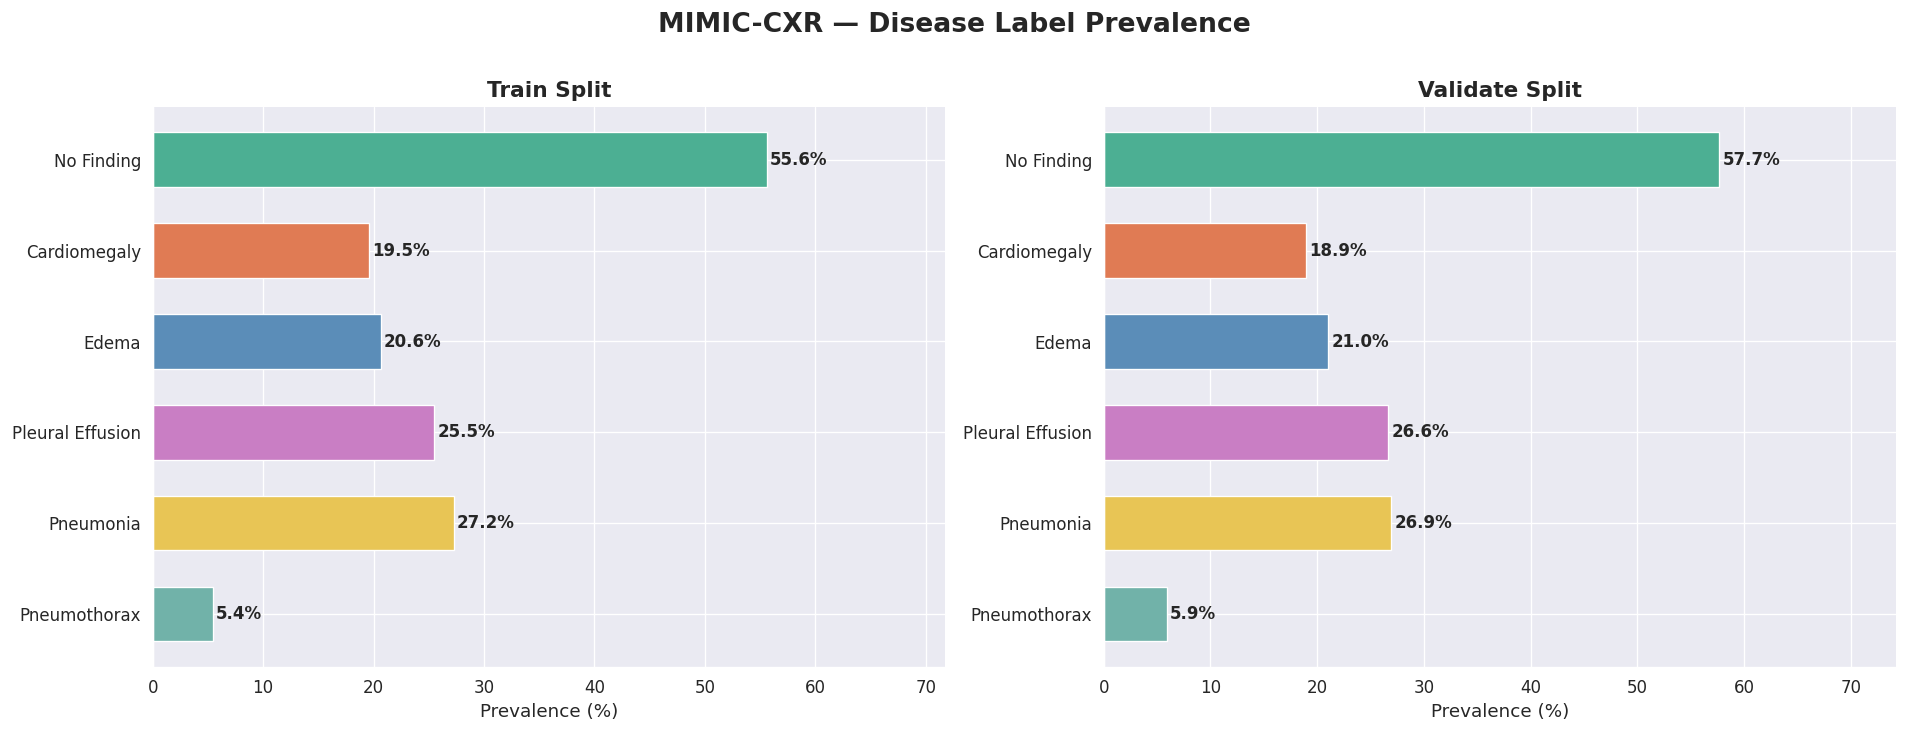

   📁 Saved: label_distribution.png


In [15]:
# ─── Visual: Label distribution bar plots ─────────────────────────────────────

PALETTE = [
    "#4CAF93", "#E07B54", "#5B8DB8", "#C97EC4",
    "#E8C555", "#71B2A9", "#F08080",
]


def plot_label_distribution(
    stats_train: pd.DataFrame,
    stats_val: pd.DataFrame,
    label_cols: List[str],
) -> None:
    """
    Plot side-by-side prevalence bar charts for train and validate splits.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("MIMIC-CXR — Disease Label Prevalence", fontsize=16, fontweight="bold", y=1.01)

    for ax, (stats_df, split) in zip(axes, [(stats_train, "Train"), (stats_val, "Validate")]):
        labels_present = [l for l in label_cols if l in stats_df.index]
        prevalences    = stats_df.loc[labels_present, "Prevalence (%)"].values
        colors = PALETTE[:len(labels_present)]

        bars = ax.barh(
            labels_present[::-1],
            prevalences[::-1],
            color=colors[::-1],
            edgecolor="white",
            linewidth=0.8,
            height=0.6,
        )

        for bar, val in zip(bars, prevalences[::-1]):
            ax.text(
                bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", ha="left", fontsize=10, fontweight="bold"
            )

        ax.set_title(f"{split} Split", fontsize=13, fontweight="bold")
        ax.set_xlabel("Prevalence (%)", fontsize=11)
        ax.set_xlim(0, max(prevalences) * 1.2 + 5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="y", labelsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "label_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   📁 Saved: label_distribution.png")


plot_label_distribution(train_stats, val_stats, ALL_LABEL_COLS)

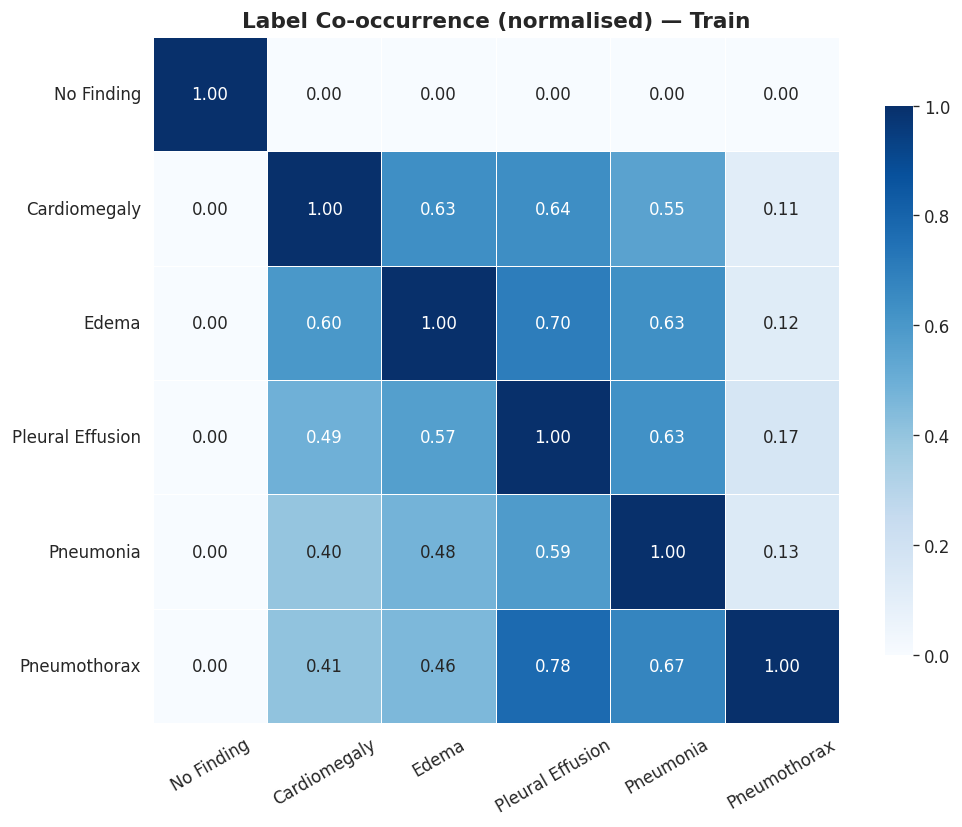

   📁 Saved: cooccurrence_train.png


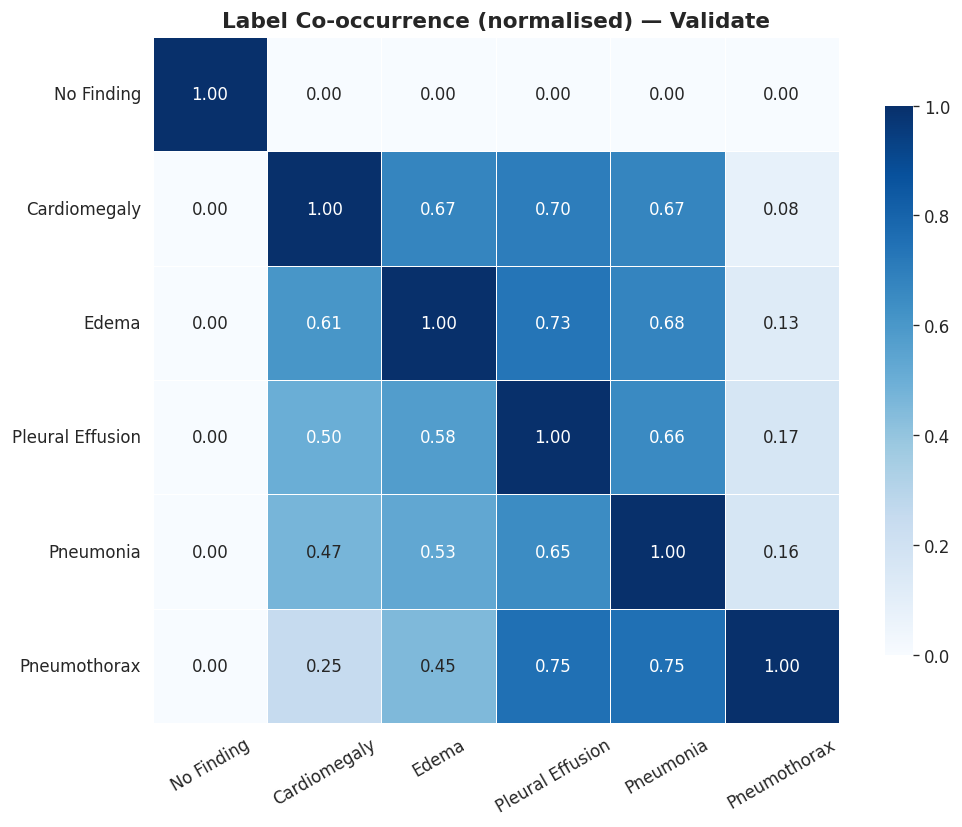

   📁 Saved: cooccurrence_validate.png


In [16]:
# ─── Visual: Co-occurrence heatmap ────────────────────────────────────────────

def plot_cooccurrence(
    df: pd.DataFrame,
    label_cols: List[str],
    split_name: str,
) -> None:
    """
    Plot a label co-occurrence heatmap (normalised by row total).
    """
    sub = df[label_cols].fillna(0).astype(int)
    cooccurrence = sub.T.dot(sub)
    norm_cooccurrence = cooccurrence.div(cooccurrence.values.diagonal(), axis=0)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        norm_cooccurrence,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        linewidths=0.5,
        square=True,
        ax=ax,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(f"Label Co-occurrence (normalised) — {split_name}", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    fname = f"cooccurrence_{split_name.lower()}.png"
    plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   📁 Saved: {fname}")


plot_cooccurrence(df_train_labeled, ALL_LABEL_COLS, "Train")
plot_cooccurrence(df_val_labeled,   ALL_LABEL_COLS, "Validate")

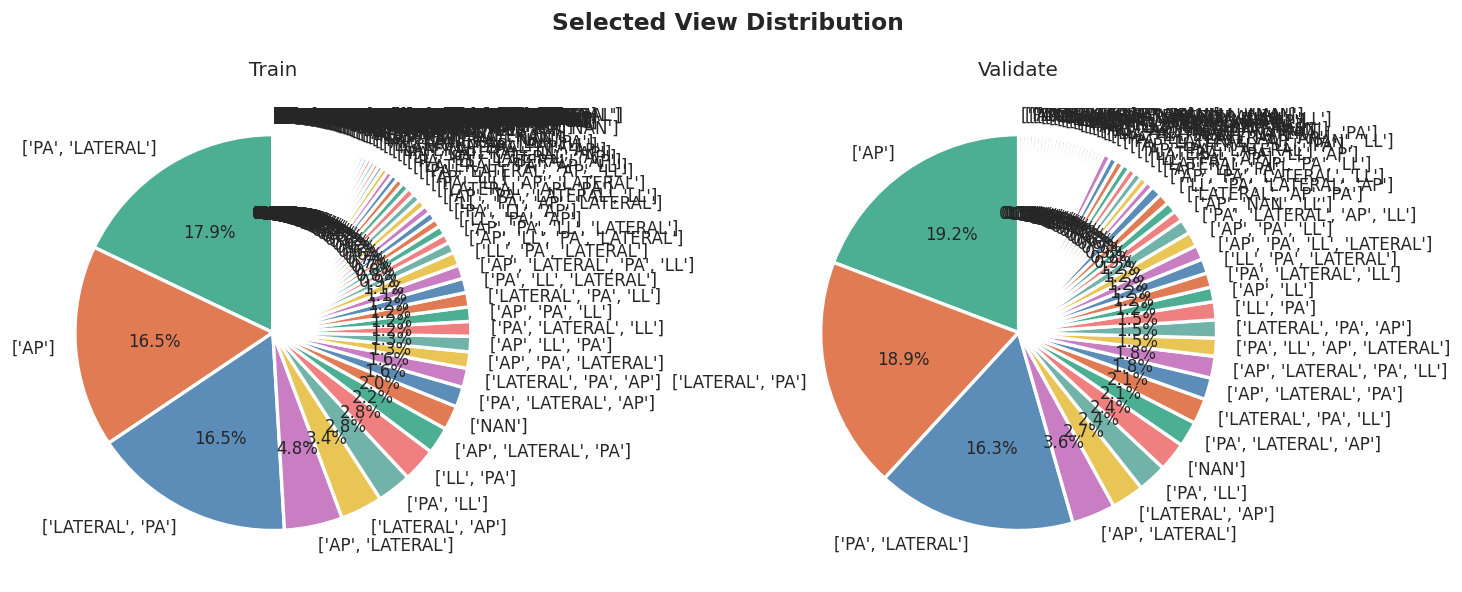

   📁 Saved: view_distribution.png


In [17]:
# ─── Visual: View distribution pie charts ─────────────────────────────────────

def plot_view_distribution(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
) -> None:
    """Plot the selected view distribution for both splits."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Selected View Distribution", fontsize=14, fontweight="bold")

    for ax, (df, split) in zip(axes, [(df_train, "Train"), (df_val, "Validate")]):
        counts = df["selected_view"].value_counts()
        ax.pie(
            counts.values,
            labels=counts.index,
            autopct="%1.1f%%",
            colors=PALETTE[:len(counts)],
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2},
        )
        ax.set_title(split, fontsize=12)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "view_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   📁 Saved: view_distribution.png")


plot_view_distribution(df_train_labeled, df_val_labeled)

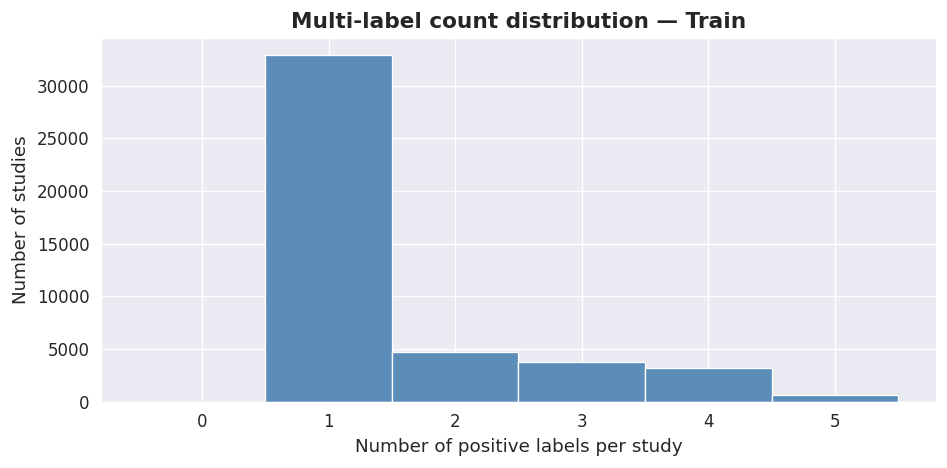

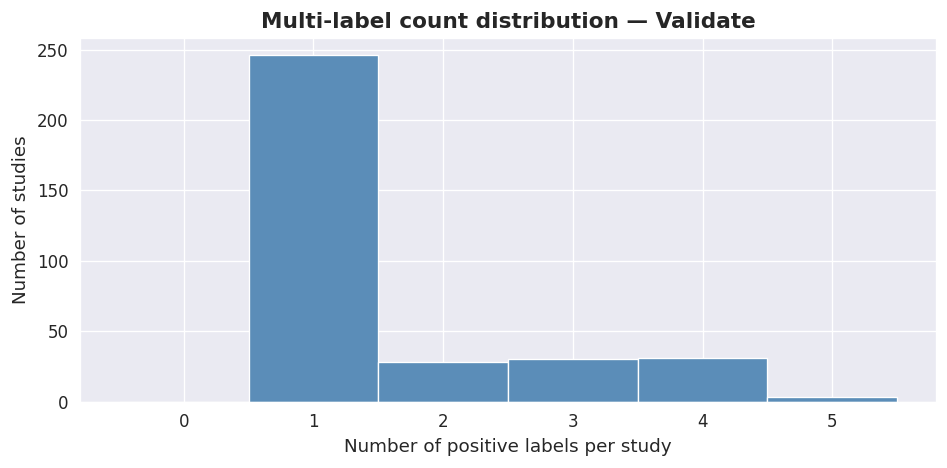

In [18]:
# ─── Multi-label distribution histogram ──────────────────────────────────────

def plot_label_count_histogram(df: pd.DataFrame, label_cols: List[str], split: str) -> None:
    """Plot distribution of how many labels each study has."""
    label_counts = df[label_cols].fillna(0).astype(int).sum(axis=1)

    fig, ax = plt.subplots(figsize=(8, 4))
    bins = range(0, label_counts.max() + 2)
    ax.hist(label_counts, bins=bins, color="#5B8DB8", edgecolor="white", linewidth=0.8, align="left")
    ax.set_xlabel("Number of positive labels per study", fontsize=11)
    ax.set_ylabel("Number of studies", fontsize=11)
    ax.set_title(f"Multi-label count distribution — {split}", fontsize=13, fontweight="bold")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"label_count_hist_{split.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_label_count_histogram(df_train_labeled, ALL_LABEL_COLS, "Train")
plot_label_count_histogram(df_val_labeled,   ALL_LABEL_COLS, "Validate")

In [19]:
# ─── Save CSVs ────────────────────────────────────────────────────────────────

out_train_path = OUTPUT_DIR / CFG.out_train_csv
out_val_path   = OUTPUT_DIR / CFG.out_val_csv
out_stats_path = OUTPUT_DIR / CFG.out_stats_json

df_train_labeled.to_csv(out_train_path, index=False)
df_val_labeled.to_csv(out_val_path,   index=False)

print(f"✅ Saved: {out_train_path}  ({out_train_path.stat().st_size / 1_048_576:.2f} MB)")
print(f"✅ Saved: {out_val_path}  ({out_val_path.stat().st_size / 1_048_576:.2f} MB)")

# ─── Save label statistics JSON ───────────────────────────────────────────────

def build_stats_dict(
    stats_train: pd.DataFrame,
    stats_val: pd.DataFrame,
    cfg: Config,
) -> Dict:
    """
    Assemble a comprehensive JSON-serializable statistics dictionary.
    """
    def df_to_dict(df: pd.DataFrame) -> Dict:
        return df.reset_index().to_dict(orient="records")

    return {
        "pipeline_config": {
            "uncertainty_policy": cfg.uncertainty_policy,
            "view_priority": cfg.view_priority,
            "targets": cfg.targets,
        },
        "train": {
            "n_studies": len(df_train_labeled),
            "label_stats": df_to_dict(stats_train),
        },
        "validate": {
            "n_studies": len(df_val_labeled),
            "label_stats": df_to_dict(stats_val),
        },
    }


stats_dict = build_stats_dict(train_stats, val_stats, CFG)

with open(out_stats_path, "w") as f:
    json.dump(stats_dict, f, indent=2, default=str)

print(f"✅ Saved: {out_stats_path}")

print("\n📁 All files in /kaggle/working/:")
for p in sorted(OUTPUT_DIR.iterdir()):
    size = p.stat().st_size
    print(f"   {p.name:<45}  {size / 1_048_576:.2f} MB")

✅ Saved: /kaggle/working/mimic_final_labeled_train.csv  (69.11 MB)
✅ Saved: /kaggle/working/mimic_final_labeled_validate.csv  (0.57 MB)
✅ Saved: /kaggle/working/label_statistics.json

📁 All files in /kaggle/working/:
   .virtual_documents                             0.00 MB
   cooccurrence_train.png                         0.10 MB
   cooccurrence_validate.png                      0.10 MB
   label_count_hist_train.png                     0.04 MB
   label_count_hist_validate.png                  0.03 MB
   label_distribution.png                         0.07 MB
   label_statistics.json                          0.00 MB
   mimic_final_labeled_train.csv                  69.11 MB
   mimic_final_labeled_validate.csv               0.57 MB
   view_distribution.png                          0.37 MB


In [20]:
# ─── Sample reports for manual label inspection ───────────────────────────────

def inspect_sample(
    df: pd.DataFrame,
    label_cols: List[str],
    n: int = 10,
    seed: int = 42,
) -> None:
    """
    Print a random sample of report → label pairs for manual review.

    Parameters
    ----------
    df : pd.DataFrame
        Labeled study dataframe.
    label_cols : List[str]
        Label column names.
    n : int
        Number of samples to print.
    seed : int
        Random seed.
    """
    sample = df[df["report"] != ""].sample(min(n, len(df)), random_state=seed)

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f"{'─'*80}")
        print(f"[{i}/{n}]  subject={row['subject_id']}  study={row['study_id']}  view={row['selected_view']}")
        print()

        report_preview = row["report"]
        if len(report_preview) > 500:
            report_preview = report_preview[:497] + "..."
        print(f"  REPORT  : {report_preview}")
        print()

        label_str = "  ".join(
            f"{col}={int(row[col]) if pd.notna(row[col]) else 'NaN'}"
            for col in label_cols
        )
        print(f"  LABELS  : {label_str}")
        print()


print("🔬 MANUAL INSPECTION — 10 SAMPLES FROM TRAINING SET\n")
inspect_sample(df_train_labeled, ALL_LABEL_COLS, n=10, seed=CFG.random_seed)

🔬 MANUAL INSPECTION — 10 SAMPLES FROM TRAINING SET

────────────────────────────────────────────────────────────────────────────────
[1/10]  subject=19942660  study=s56770396  view=['AP', 'LATERAL']

  REPORT  : ['findings: ap and lateral views of the chest. the lungs are grossly clear. the cardiomediastinal silhouette is within normal limits. there is no effusion or pneumothorax. no displaced fractures identified. impression: no acute cardiopulmonary process.']

  LABELS  : No Finding=1  Cardiomegaly=0  Edema=0  Pleural Effusion=0  Pneumonia=0  Pneumothorax=0

────────────────────────────────────────────────────────────────────────────────
[2/10]  subject=19962585  study=s54068345  view=['LATERAL', 'PA']

  REPORT  : ['findings: the lungs are well expanded and clear. there is no pleural effusion or pneumothorax. the cardiomediastinal silhouette is unremarkable. impression: no acute cardiopulmonary process.']

  LABELS  : No Finding=1  Cardiomegaly=0  Edema=0  Pleural Effusion=0  Pneum

In [21]:
# ─── Full 100-sample inspection (saved to file for review) ────────────────────

def save_inspection_report(
    df: pd.DataFrame,
    label_cols: List[str],
    n: int,
    output_path: Path,
    seed: int = 42,
) -> None:
    """
    Save full manual inspection report to a text file.

    Parameters
    ----------
    df : pd.DataFrame
        Labeled study dataframe.
    label_cols : List[str]
        Label column names.
    n : int
        Number of samples.
    output_path : Path
        Path to write the report.
    seed : int
        Random seed.
    """
    sample = df[df["report"] != ""].sample(min(n, len(df)), random_state=seed)
    lines = []
    lines.append("MIMIC-CXR Manual Label Inspection Report")
    lines.append(f"N = {len(sample)} samples | Uncertainty policy = {CFG.uncertainty_policy}")
    lines.append("=" * 80)
    lines.append("")

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        lines.append("-" * 80)
        lines.append(f"[{i}]  subject={row['subject_id']}  study={row['study_id']}  view={row['selected_view']}")
        lines.append(f"IMAGE PATH: {row['image_path']}")
        lines.append("")
        lines.append(f"REPORT:\n{row['report']}")
        lines.append("")
        label_str = "  ".join(
            f"{col}={int(row[col]) if pd.notna(row[col]) else 'NaN'}"
            for col in label_cols
        )
        lines.append(f"LABELS: {label_str}")
        lines.append("")

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"✅ Inspection report saved: {output_path}  ({output_path.stat().st_size / 1024:.1f} KB)")


save_inspection_report(
    df_train_labeled,
    ALL_LABEL_COLS,
    n=CFG.inspection_sample_n,
    output_path=OUTPUT_DIR / "manual_inspection_report.txt",
    seed=CFG.random_seed,
)

✅ Inspection report saved: /kaggle/working/manual_inspection_report.txt  (173.5 KB)


In [22]:
# ─── Final summary ────────────────────────────────────────────────────────────

print("=" * 70)
print(" MIMIC-CXR LABEL GENERATION — PIPELINE COMPLETE ")
print("=" * 70)
print()
print(f"  Train studies created    : {len(df_train_labeled):>8,}")
print(f"  Validate studies created : {len(df_val_labeled):>8,}")
print()
print("  Label prevalence (train):")
for _, row in train_stats.iterrows():
    label_name = row.name if hasattr(row, 'name') else ''
    print(f"    {label_name:<22} → {row['Positive']:>6,} positive  ({row['Prevalence (%)']:>5.1f}%)")
print()
print("  Output files:")
for fname in [CFG.out_train_csv, CFG.out_val_csv, CFG.out_stats_json,
               "label_distribution.png", "manual_inspection_report.txt"]:
    fpath = OUTPUT_DIR / fname
    exists = "✅" if fpath.exists() else "❌"
    print(f"    {exists} {fname}")
print()
print("  Ready for downstream tasks:")
print("    ✅ BiomedCLIP (image_path)")
print("    ✅ BioClinicalBERT (report)")
print("    ✅ Multimodal Fusion")
print("    ✅ RAG indexing")
print("    ✅ Explainability")
print()
print("=" * 70)

 MIMIC-CXR LABEL GENERATION — PIPELINE COMPLETE 

  Train studies created    :   45,224
  Validate studies created :      338

  Label prevalence (train):
    No Finding             → 25,148.0 positive  ( 55.6%)
    Cardiomegaly           → 8,837.0 positive  ( 19.5%)
    Edema                  → 9,329.0 positive  ( 20.6%)
    Pleural Effusion       → 11,519.0 positive  ( 25.5%)
    Pneumonia              → 12,319.0 positive  ( 27.2%)
    Pneumothorax           → 2,452.0 positive  (  5.4%)

  Output files:
    ✅ mimic_final_labeled_train.csv
    ✅ mimic_final_labeled_validate.csv
    ✅ label_statistics.json
    ✅ label_distribution.png
    ✅ manual_inspection_report.txt

  Ready for downstream tasks:
    ✅ BiomedCLIP (image_path)
    ✅ BioClinicalBERT (report)
    ✅ Multimodal Fusion
    ✅ RAG indexing
    ✅ Explainability

